In [123]:
import pandas as pd
import numpy as np

df = pd.read_csv("Crop_recommendation.csv")
df.head()


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [125]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData types:\n", df.dtypes)


Shape: (2200, 8)

Columns:
 Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

Data types:
 N                int64
P                int64
K                int64
temperature    float64
humidity       float64
ph             float64
rainfall       float64
label           object
dtype: object


In [127]:
df.isnull().sum()


N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [129]:
df.dropna(inplace=True)


In [131]:
df.duplicated().sum()


0

In [133]:
df.drop_duplicates(inplace=True)


In [135]:
df['label'].value_counts()


label
rice           100
maize          100
jute           100
cotton         100
coconut        100
papaya         100
orange         100
apple          100
muskmelon      100
watermelon     100
grapes         100
mango          100
banana         100
pomegranate    100
lentil         100
blackgram      100
mungbean       100
mothbeans      100
pigeonpeas     100
kidneybeans    100
chickpea       100
coffee         100
Name: count, dtype: int64

In [137]:
X = df.drop("label", axis=1)
y = df["label"]


In [139]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Total crops:", len(label_encoder.classes_))
print("Crop classes:", label_encoder.classes_)


Total crops: 22
Crop classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [141]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # VERY IMPORTANT
)


In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [145]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial",
    solver="lbfgs"
)

log_model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=3000, multi_class='multinomial')

In [147]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_log = log_model.predict(X_test_scaled)

print("🔵 Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred_log, target_names=label_encoder.classes_
))


🔵 Logistic Regression Accuracy: 0.9727272727272728

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      1.00      0.98        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.95      1.00      0.98        20
      coffee       1.00      1.00      1.00        20
      cotton       0.95      1.00      0.98        20
      grapes       1.00      1.00      1.00        20
        jute       0.83      1.00      0.91        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.94      0.85      0.89        20
       maize       1.00      0.95      0.97        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.90      0.90      0.90        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
     

In [149]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [150]:
y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(
    y_test, y_pred_rf, target_names=label_encoder.classes_
))


Random Forest Accuracy: 0.9954545454545455

Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange 

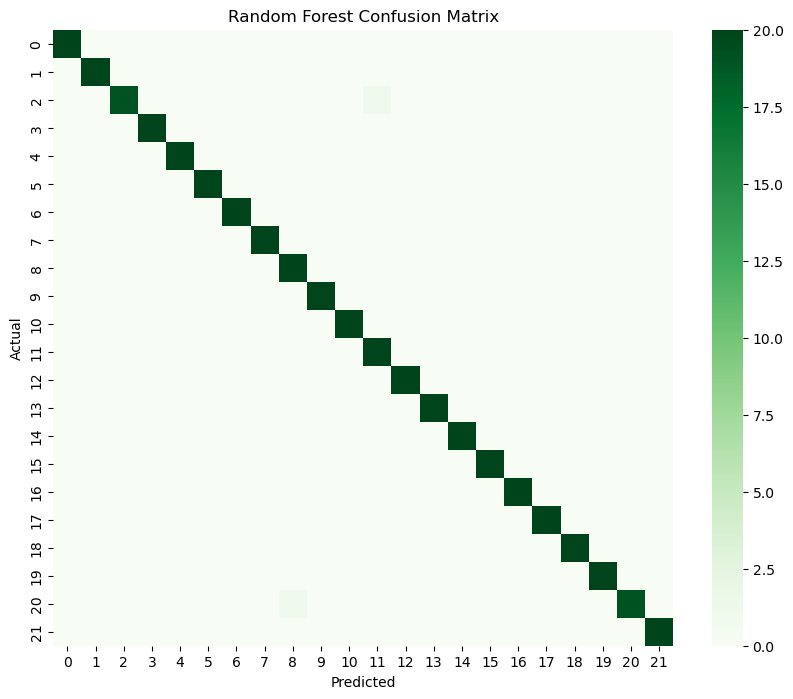

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap="Greens")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [163]:
import numpy as np
import pandas as pd

def predict_top_3(model, scaler, label_encoder, input_data):
    """
    input_data: dict with keys
    N, P, K, temperature, humidity, ph, rainfall
    """

    df_input = pd.DataFrame([input_data])
    scaled_input = scaler.transform(df_input)

    probabilities = model.predict_proba(scaled_input)[0]

    top3_indices = np.argsort(probabilities)[-3:][::-1]

    top3 = []
    for idx in top3_indices:
        crop_name = label_encoder.inverse_transform([idx])[0]
        confidence = round(probabilities[idx] * 100, 2)
        top3.append((crop_name, confidence))

    return top3


In [165]:
sample_input = {
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 20.8,
    "humidity": 82,
    "ph": 6.5,
    "rainfall": 202
}

print(predict_top_3(rf_model, scaler, label_encoder, sample_input))


[('rice', 94.67), ('jute', 5.33), ('watermelon', 0.0)]


In [169]:
import joblib, os

os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/crop_new_model.pkl")
joblib.dump(scaler, "models/scaler_new.pkl")
joblib.dump(label_encoder, "models/label_encoder_new.pkl")


['models/label_encoder_new.pkl']

In [171]:
print("Model:", type(rf_model))
print("Scaler:", type(scaler))
print("Encoder:", type(label_encoder))

Model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Scaler: <class 'sklearn.preprocessing._data.StandardScaler'>
Encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>
